In [1]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly
import streamlit as st
import joblib

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILEPATH = "C:\\Users\\audre\\Downloads\\differentiated+thyroid+cancer+recurrence\\Thyroid_Diff.csv"
df = pd.read_csv(FILEPATH)
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [3]:
st.title = "Thyroid Cancer Recurrence Data Prediction"

## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

In [5]:
## Check for missing data
df.isna().sum()

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

In [6]:
## Describe data distribution
df.describe(include="all")

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,NaN,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,NaN,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,NaN,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275
mean,40.866841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.134494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [7]:
## Understanding distribution of target
col_y = 'Recurred'

### 2.3.1.2 Understanding distribution of features

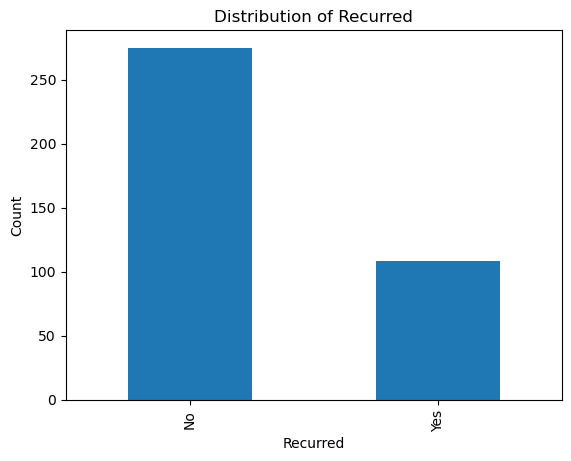

In [8]:
## Understanding distribution of features
df['Recurred'].value_counts().plot(kind='bar')
plt.title('Distribution of Recurred')
plt.xlabel('Recurred')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Count')

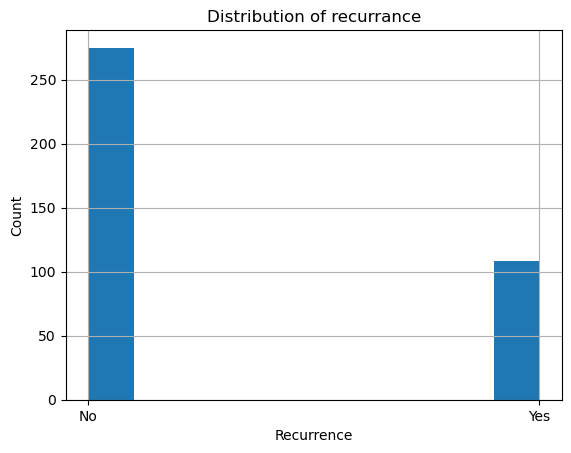

In [9]:
## Plot histogram
df[col_y].hist()
plt.title(f"Distribution of recurrance")
plt.suptitle('') # Remove default title by Pandas
plt.xlabel("Recurrence")
plt.ylabel("Count")


In [10]:
## Plot boxplot for different features


### 2.3.2 Understanding relationship between variables

In [11]:
## Check datatypes for each column
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all␣ categorical columns
## Display correlation matrix
df_corr = df[col_numeric].corr()
df_corr


,Age
Age,1.0


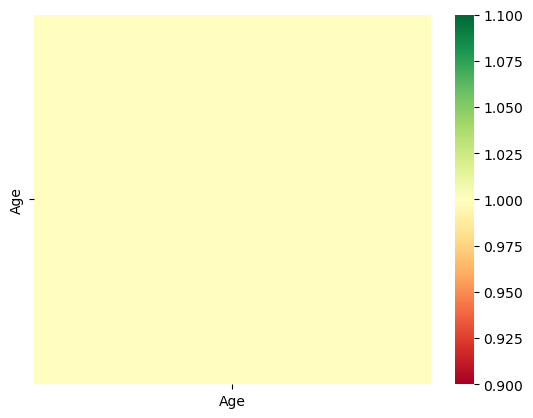

In [19]:
## Plot heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

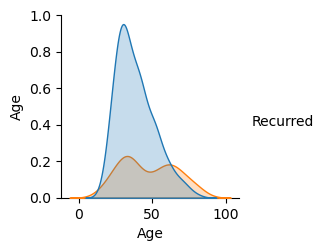

In [20]:
## Plot pairplot
sns.pairplot(df, hue=col_y)
plt.show()


# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Clean data


NameError: name 'model' is not defined

## 3.2 Train-Test Split

In [24]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all␣categorical columns
## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}')


Gender (2): <ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
Smoking (2): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Hx Smoking (2): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Hx Radiothreapy (2): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Thyroid Function (5): <ArrowStringArray>
[                  'Euthyroid',    'Clinical Hyperthyroidism',
     'Clinical Hypothyroidism', 'Subclinical Hyperthyroidism',
  'Subclinical Hypothyroidism']
Length: 5, dtype: str
Physical Examination (5): <ArrowStringArray>
[ 'Single nodular goiter-left',         'Multinodular goiter',
 'Single nodular goiter-right',                      'Normal',
              'Diffuse goiter']
Length: 5, dtype: str
Adenopathy (6): <ArrowStringArray>
['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior']
Length: 6, dtype: str
Pathology (4): <ArrowStringArray>
['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell']
Length: 4, dtype: str
Focality (2): <ArrowStringArray>
['Un

C:\Users\audre\AppData\Local\Temp\ipykernel_22664\715867812.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_categorical = df.select_dtypes(include=['object']).columns ## Select all␣categorical columns


In [ ]:
## Split data into features (X) and target (y)
y = df[col_y] ## Select target column
# col_irrelevant = [col_y]
X = df.drop(col_irrelevant, axis=1) ## Select feature columns
## One-Hot Encoding
X = pd.get_dummies(X,
drop_first=True ## Remove redundant information
)
X

In [22]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

NameError: name 'X' is not defined

# 4. Modelling

### 4.2 Train Model

In [14]:
## Initialise and train model


# 5. Model Evaluation

In [15]:
## Evaluate model


In [16]:
## New data

## Predict
